# Exercises for Section 3.3 Introduction to hypothesis testing

This notebook contains the solutions to the exercises
from [Section 3.3 Introduction to hypothesis testing]()
in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn pandas ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
)
%config InlineBackend.figure_format = "retina"

<Figure size 640x480 with 0 Axes>

In [4]:
# Simplified int and float __repr__
np.set_printoptions(legacy='1.25')

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


$\def\stderr#1{\mathbf{se}_{#1}}$
$\def\stderrhat#1{\hat{\mathbf{se}}_{#1}}$
$\newcommand{\Mean}{\textbf{Mean}}$
$\newcommand{\Var}{\textbf{Var}}$
$\newcommand{\Std}{\textbf{Std}}$
$\newcommand{\Freq}{\textbf{Freq}}$
$\newcommand{\RelFreq}{\textbf{RelFreq}}$
$\newcommand{\DMeans}{\textbf{DMeans}}$
$\newcommand{\Prop}{\textbf{Prop}}$
$\newcommand{\DProps}{\textbf{DProps}}$
$$
\newcommand{\CI}[1]{\textbf{CI}_{#1}}
\newcommand{\CIL}[1]{\textbf{L}_{#1}}
\newcommand{\CIU}[1]{\textbf{U}_{#1}}
\newcommand{\ci}[1]{\textbf{ci}_{#1}}
\newcommand{\cil}[1]{\textbf{l}_{#1}}
\newcommand{\ciu}[1]{\textbf{u}_{#1}}
$$
(this cell contains the macro definitions like $\stderr{\overline{\mathbf{x}}}$, $\stderrhat{}$, $\Mean$, ...)

### Estimator functions defined in Section 3.1

In [6]:
# def mean(sample):
#     return sum(sample) / len(sample)

# def var(sample):
#     xbar = mean(sample)
#     sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
#     return sumsqdevs / (len(sample)-1)

# def std(sample):
#     s2 = var(sample)
#     return np.sqrt(s2)

# def dmeans(xsample, ysample):
#     dhat = mean(xsample) - mean(ysample)
#     return dhat

## Exercises

### E3.23

Compute the $p$-value for hypothesis test of the mean in Batch 05 of the kombucha dataset.

In [7]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample05 = kombucha[kombucha["batch"]==5]["volume"]
len(ksample05)

40

In [8]:
ksample05.head()

107     998.35
108     998.92
109    1005.38
110    1007.20
111    1010.62
Name: volume, dtype: float64

In [9]:
# Population data model under H0
from scipy.stats import norm
rvK0 = ...

# Set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
kbars40 = ...

# Compute the observed mean
obsmean05 = ...

# Compute the p-value of `obsmean05` under H0
obsdev05 = ...
tails = ...
pvalue05 = ...

### E3.24

Compute the $p$-value for hypothesis test of the mean in Batch 06 of the kombucha dataset.

In [13]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample06 = kombucha[kombucha["batch"]==6]["volume"]
len(ksample06)

40

In [14]:
ksample05.head()

107     998.35
108     998.92
109    1005.38
110    1007.20
111    1010.62
Name: volume, dtype: float64

In [15]:
# Population data model under H0
from scipy.stats import norm
rvK0 = ...

# Set the random seed to a particular value to get a reproducible result
np.random.seed(43)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
kbars40 = ...

# Compute the observed mean
obsmean06 = ...

# Compute the p-value of `obsmean06` under H0
obsdev06 = ...
tails = ...
pvalue06 = ...

### E3.25

Run the test for the variance on Batch 01.

In [19]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample01 = kombucha[kombucha["batch"]==1]["volume"]
len(ksample01)

40

In [20]:
ksample01.head()

0    1016.24
1     993.88
2     994.72
3     989.27
4    1008.65
Name: volume, dtype: float64

In [21]:
# Define the variance estimator function
def var(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return sumsqdevs / (len(sample)-1)

The $p$-value is greater than $\alpha=0.05$
so we fail to reject $H_0$.

### E3.26



In [26]:
# The observed data sample
isample = [101.9, 100.4,  99.9, 100.4, 101.1,
           100.8, 100.8, 101.2,  99.8, 102.5]

### E3.27



In [31]:

bsample = [15, 14,  9, 10, 11, 19, 10, 12, 12, 11,  8, 15]

### E3.28




In [35]:
# Sampling distribution under H0
rvDbar0 = norm(0.87, 0.445)

np.random.seed(47)
dbars = rvDbar0.rvs(10000)

# Observed estimate from Principe
obsdmean = 1.61

# One-sided p-value: Einstein predicts more deflection than Newton
tail = [dbar for dbar in dbars if dbar >= obsdmean]
pvalue = len(tail) / len(dbars)

print("p-value =", pvalue)

p-value = 0.048


In [36]:
import numpy as np
from scipy.stats import norm

# Observed data
dsample = np.array([0.63, 1.12, 1.61, 2.10, 2.59])

# Population data model under H0
rvD0 = norm(0.87, 0.99)

# Set the random seed to get a reproducible result
np.random.seed(46)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
dbars5 = gen_sampling_dist(rvD0, estfunc=np.mean, n=5)

# Compute the observed mean
obsdmean = np.mean(dsample)
print("obsmean =", obsdmean)

# Compute the one-sided p-value under H0
tail = [dbar for dbar in dbars5 if dbar >= obsdmean]
pvalue = len(tail) / len(dbars5)
print("p-value =", pvalue)

obsmean = 1.61
p-value = 0.0495


In [37]:
# Standard normal distribution under H0
rvZ0 = norm(0, 1)

# Compute the standard error and z-statistic
se = 0.99 / np.sqrt(5)
zscore = (obsdmean - 0.87) / se
print("z =", zscore)

# Compute the one-sided p-value
pvalue = rvZ0.sf(zscore)
print("p-value =", pvalue)

z = 1.6714043468180249
p-value = 0.047320918959554


In [38]:
import numpy as np

# Observed data
dsample = [0.63, 1.12, 1.61, 2.10, 2.59]

# Compute sample statistics
n = len(dsample)
obsdmean = np.mean(dsample)
obsdstd = np.std(dsample, ddof=1)
se = obsdstd / np.sqrt(n)
print("mean =", obsdmean)
print("std =", obsdstd)

# Compute the t-statistic
obst = (obsdmean - 0.87) / se
print("t =", obst)

# Reference distribution under H0
from scipy.stats import t as tdist
rvT0 = tdist(df=n-1)

# Compute the one-sided p-value
pvalue = 1 - rvT0.cdf(obst)
print("p-value =", pvalue)

mean = 1.61
std = 0.7747580267412529
t = 2.135751094196103
p-value = 0.04978101360614473


### E3.29



## CUT MATERIAL 

### Mean test on batch 05 (estimated variance)

Correctly rejects this as an irregular batch.

count      40.000000
mean     1002.534750
std         6.553409
min       992.090000
25%       998.515000
50%      1002.060000
75%      1004.870000
max      1027.190000
Name: volume, dtype: float64

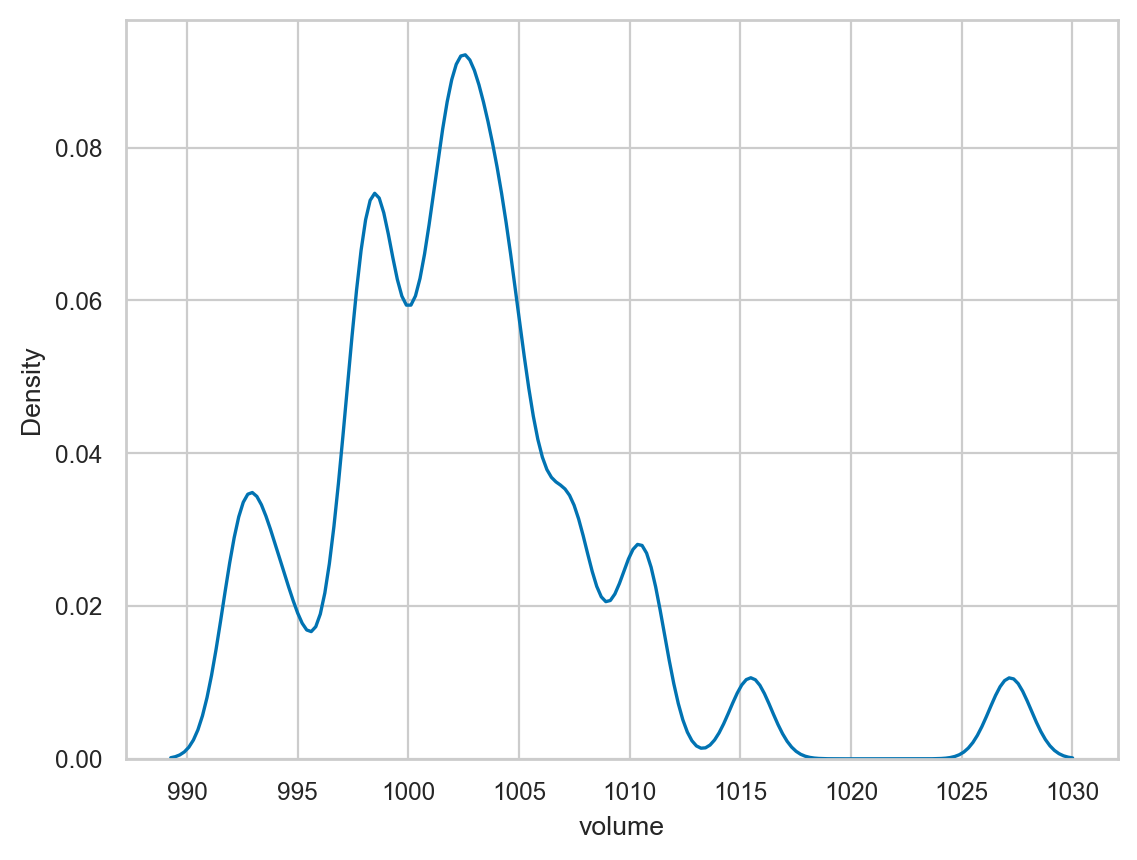

In [42]:
sns.kdeplot(ksample05, bw_adjust=0.3)
ksample05.describe()

### Cohen's d via bootstrap

### Electric scooters

An electric scooter manufacturer launched a new model with large battery and claims the range of the scooter is 45 km. A distributor wants to put this claim to a test, and has collected data from 15 different electric scooters to measure the maximum range of trips, to see how long the battery lasts. We want to know if the data supports the manufacturer's claim.

The obtained the data $\texttt{ds} = [43.5, 44.8, 42.9, 46.2, 44.1, 43.8, 45.5, 43.4, 44.9, 42.7, 44.6, 47.0, 43.0, 44.2, 45.3]$.

Assume the theoretical distribution is normally distributed $D_0 \sim \mathcal{N}(45, \sigma_{D_0})$,
where $\sigma_{D_0}$ is unknown so we'll estimate it from the sample variance $\sigma_{D_0} \approx \texttt{dstd} = \texttt{std(ds)}$.


In [43]:
# sample
ds = [43.5, 44.8, 42.9, 46.2, 44.1, 43.8, 45.5,
      43.4, 44.9, 42.7, 44.6, 47.0, 43.0, 44.2, 45.3]

In [44]:
from ministats import mean, std
dbar = mean(ds)
dstd = std(ds)

In [45]:
from scipy.stats import norm
muD0 = 45
Dbar0 = norm(45, dstd)

In [46]:
from ministats import gen_sampling_dist

np.random.seed(42)
dbars0 = gen_sampling_dist(Dbar0, estfunc=mean, n=15)

In [47]:
obsdev = abs(dbar - muD0)
tails = [v for v in dbars0 if abs(v-muD0) >= obsdev]
pvalue = len(tails) / len(dbars0)
pvalue

0.0622

In [48]:
from ministats import simulation_test_mean

np.random.seed(42)
simulation_test_mean(ds, mu0=muD0, sigma0=dstd)

0.0612